<a href="https://colab.research.google.com/github/Prashantkumartalan43/EDA/blob/main/superstore_sales_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("SuperStoreOrders.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [7]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [8]:
df.dropna(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["order_date"] = pd.to_datetime(df["order_date"], format='mixed')
df["ship_date"] = pd.to_datetime(df["ship_date"], format='mixed')

In [11]:
df['sales'] = df['sales'].astype(str).str.replace(r'[$,\s]', '', regex=True)
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [12]:
df["year"] = df["year"].astype(object)

In [13]:
print("Total Sales:", df["sales"].sum())
print("Average Sales:", df["sales"].mean())

Total Sales: 12642905
Average Sales: 246.49844024176252


In [14]:
# Best selling category

df.groupby("category")["sales"].sum().sort_values(ascending=False)

,sales
category,
Technology,4744691
Furniture,4110884
Office Supplies,3787330


In [15]:
# Best region

df.groupby("region")["sales"].sum().sort_values(ascending=False)

,sales
region,
Central,2822399
South,1600960
North,1248192
Oceania,1100207
Southeast Asia,884438
North Asia,848349
EMEA,806184
Africa,783776
Central Asia,752839


In [16]:
# Highest sales month

df.groupby(df["order_date"].dt.month)["sales"].sum().sort_values(ascending=False)

,sales
order_date,
12,1383376
11,1377692
8,1247542
9,1244201
6,1152392
10,1120810
5,976429
3,951379
4,851641


In [17]:
# Highest profit month

df.groupby(df["order_date"].dt.month)["profit"].sum().sort_values(ascending=False)

,profit
order_date,
12,161550.20268
11,154704.62196
6,144458.78866
10,138733.88830
8,135583.35630
9,128737.11324
3,123893.00142
5,112609.29714
2,96425.03602


In [18]:
# Top 10 customers

df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10)

,sales
customer_name,
Tom Ashbrook,40489
Tamara Chand,37453
Greg Tran,35552
Christopher Conant,35187
Sean Miller,35170
Bart Watters,32315
Natalie Fritzler,31778
Fred Hopkins,30404
Jane Waco,30288


In [19]:
# Top 10 products

df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)

,sales
product_name,
"Apple Smart Phone, Full Size",86936
"Cisco Smart Phone, Full Size",76441
"Motorola Smart Phone, Full Size",73159
"Nokia Smart Phone, Full Size",71904
Canon imageCLASS 2200 Advanced Copier,61600
"Hon Executive Leather Armchair, Adjustable",58200
"Office Star Executive Leather Armchair, Adjustable",50667
"Harbour Creations Executive Leather Armchair, Adjustable",50120
"Samsung Smart Phone, Cordless",48654


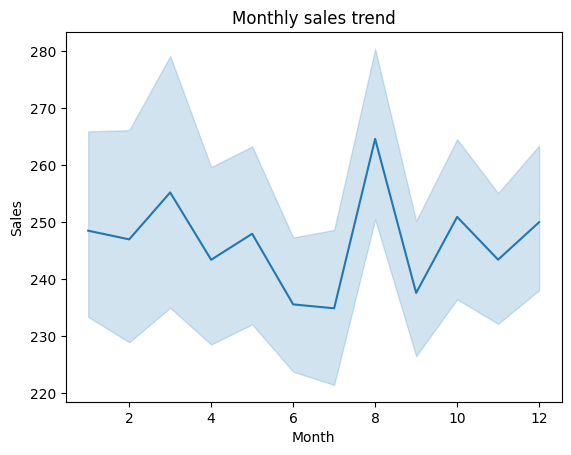

In [20]:
# Monthly sales trend

sns.lineplot(x=df["order_date"].dt.month, y=df["sales"])
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly sales trend")
plt.show()

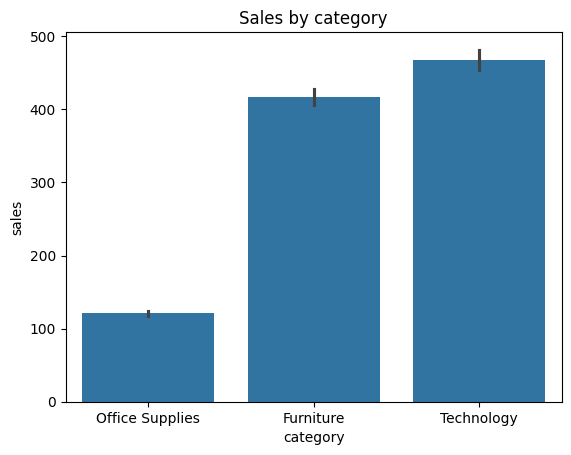

In [21]:
# Sales by category

sns.barplot(data=df, x="category", y="sales")
plt.title("Sales by category")
plt.show()

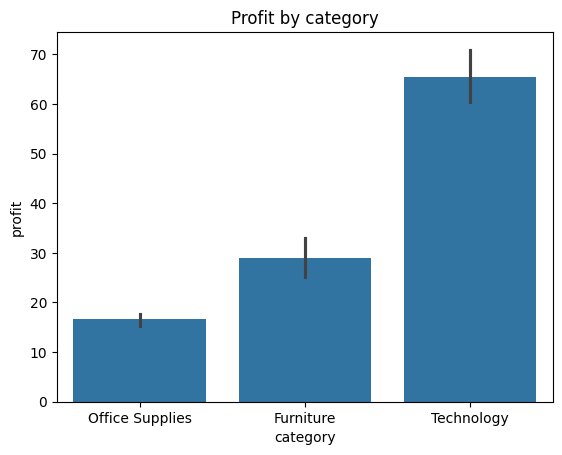

In [22]:
# profit by category

sns.barplot(data=df, x="category", y="profit")
plt.title("Profit by category")
plt.show()

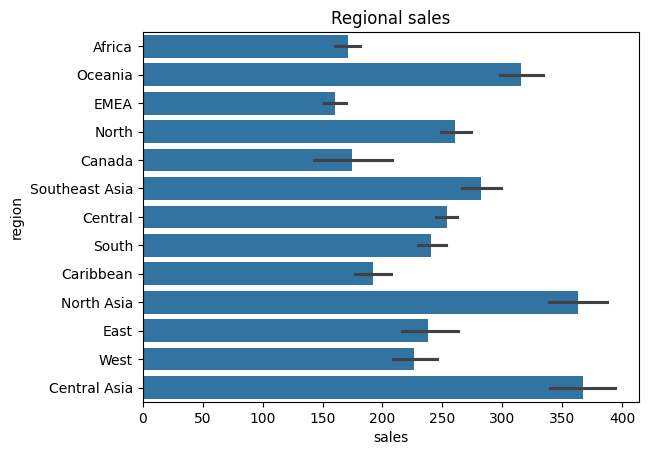

In [23]:
# regional sales

sns.barplot(data=df, x="sales", y="region")
plt.title("Regional sales")
plt.show()

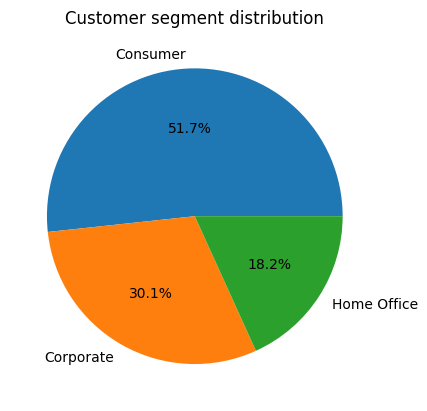

In [24]:
# Customer segment distribution

plt.pie(df["segment"].value_counts(), labels=df["segment"].value_counts().index, autopct="%1.1f%%")
plt.title("Customer segment distribution")
plt.show()

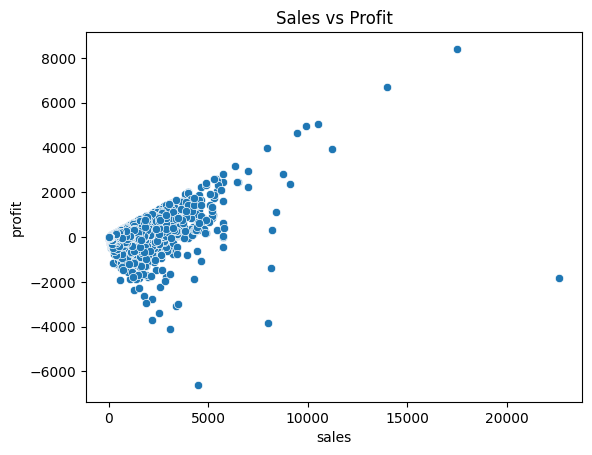

In [25]:
# Sales vs Profit

sns.scatterplot(data=df, x="sales", y="profit")
plt.title("Sales vs Profit")
plt.show()

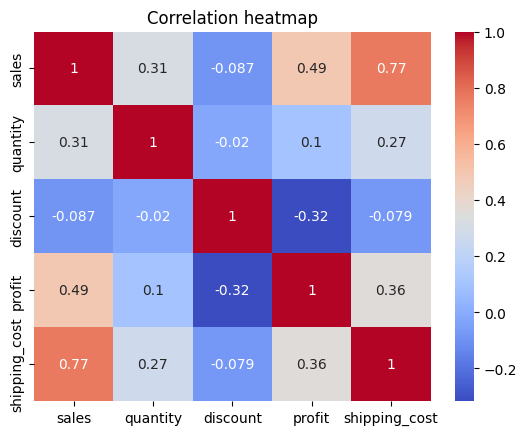

In [26]:
# Correlation heatmap
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

In [54]:
df["customer_name"].nunique()

795

In [36]:
# Which region generated the most revenue?

df.groupby("region")["sales"].sum().sort_values(ascending=False).head(1)

,sales
region,
Central,2822399


In [37]:
# Which category generated the most profit?

df.groupby("category")["sales"].sum().sort_values(ascending=False).head(1)

,sales
category,
Technology,4744691


In [39]:
# Which month had the highest sales?

df.groupby(df["order_date"].dt.month)["sales"].sum().sort_values(ascending=False).head(1)

,sales
order_date,
12,1383376


In [41]:
# Which customer purchased the most?

df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(1)

,sales
customer_name,
Tom Ashbrook,40489


In [50]:
# Which products have high sales but low profit?

product_report = df.groupby("product_name")[["sales", "profit"]].sum()

product_report["profit_margin"] = product_report["profit"] / product_report["sales"]

result = product_report[(product_report["sales"] > product_report["sales"].mean()) &
                        (product_report["profit_margin"] < product_report["profit_margin"].mean())]

result.sort_values(by="sales", ascending=False).head(5)

,sales,profit,profit_margin
product_name,,,
"Apple Smart Phone, Full Size",86936,5921.5786,0.068114
"Nokia Smart Phone, Full Size",71904,9938.1955,0.138215
"Hon Executive Leather Armchair, Adjustable",58200,5997.2541,0.103046
"Office Star Executive Leather Armchair, Adjustable",50667,4710.9840,0.092979
"Samsung Smart Phone, Cordless",48654,-198.0900,-0.004071


In [51]:
# Which region should receive more marketing investment?

region_report = df.groupby("region")[["sales", "profit"]].sum()

region_report["profit_margin"] = region_report["profit"] / region_report["sales"]

region_report["profit_margin"].sort_values(ascending=False).head(1)

,profit_margin
region,
Canada,0.266201


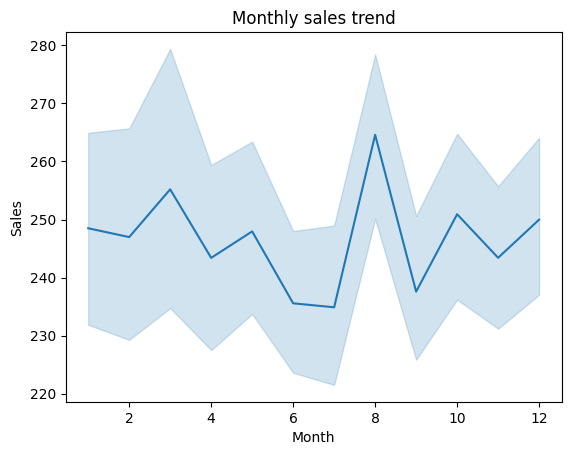

In [53]:
# Which visualization communicates monthly performance best?

sns.lineplot(x=df["order_date"].dt.month, y=df["sales"])
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly sales trend")
plt.show()